# Lab 4: Regression and Classification Evaluation Metrics

## Task 1: Data Preparation

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score, KFold
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_curve, auc, classification_report
)
from sklearn.decomposition import PCA

df = pd.read_csv('lab4.csv')

print("Dataset Shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())
print("\nDataset Info:")
df.info()

print("\nClass Distribution of target 'y':")
print(df['y'].value_counts())

Dataset Shape: (569, 32)

First 5 rows:
   Unnamed: 0  x.radius_mean  x.texture_mean  x.perimeter_mean  x.area_mean  \
0           1         13.540           14.36             87.46        566.3   
1           2         13.080           15.71             85.63        520.0   
2           3          9.504           12.44             60.34        273.9   
3           4         13.030           18.42             82.61        523.8   
4           5          8.196           16.84             51.71        201.9   

   x.smoothness_mean  x.compactness_mean  x.concavity_mean  \
0            0.09779             0.08129           0.06664   
1            0.10750             0.12700           0.04568   
2            0.10240             0.06492           0.02956   
3            0.08983             0.03766           0.02562   
4            0.08600             0.05943           0.01588   

   x.concave_pts_mean  x.symmetry_mean  ...  x.texture_worst  \
0            0.047810           0.1885  ...     

In [2]:
missing_values = df.isnull().sum().sum()
duplicate_rows = df.duplicated().sum()

print(f"Total missing values: {missing_values}")
print(f"Total duplicate rows: {duplicate_rows}")

Total missing values: 0
Total duplicate rows: 0


### 4. Feature Scaling and Justification
**Justification:** Features with larger numeric ranges will dominate the distance calculations over features with smaller ranges `StandardScaler` standardizes the features to have a mean of 0 and variance of 1, ensuring all features contribute equally to the distance calculation.

- Column `Unnamed: 0` is an index/ID, which is dropped.
- Columns `x.radius_mean` to `x.fractal_dim_worst` are our features $X$ (30 features).
- Column `y` is our target. We map `'B'` (Benign) to `1` and `'M'` (Malignant) to `0`

In [3]:
X = df.drop(columns=['Unnamed: 0', 'y'])
y = df['y'].map({'B': 1, 'M': 0})

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)
print("Scaled features description:")
print(X_scaled_df.iloc[:, :5].describe())

Scaled features description:
       x.radius_mean  x.texture_mean  x.perimeter_mean   x.area_mean  \
count   5.690000e+02    5.690000e+02      5.690000e+02  5.690000e+02   
mean   -1.998011e-16   -7.492542e-16     -9.990056e-17 -1.998011e-16   
std     1.000880e+00    1.000880e+00      1.000880e+00  1.000880e+00   
min    -2.029648e+00   -2.229249e+00     -1.984504e+00 -1.454443e+00   
25%    -6.893853e-01   -7.259631e-01     -6.919555e-01 -6.671955e-01   
50%    -2.150816e-01   -1.046362e-01     -2.359800e-01 -2.951869e-01   
75%     4.693926e-01    5.841756e-01      4.996769e-01  3.635073e-01   
max     3.971288e+00    4.651889e+00      3.976130e+00  5.250529e+00   

       x.smoothness_mean  
count       5.690000e+02  
mean        1.498508e-16  
std         1.000880e+00  
min        -3.112085e+00  
25%        -7.109628e-01  
50%        -3.489108e-02  
75%         6.361990e-01  
max         4.770911e+00  


## Task 2: Train-Test Split Analysis

In [4]:
splits = {
    '80:20': 0.20,
    '70:30': 0.30,
    '90:10': 0.10
}

results = {}

for name, test_size in splits.items():
    X_train, X_test, y_train, y_test = train_test_split(
        X_scaled, y, test_size=test_size, random_state=42, stratify=y
    )
    
    knn = KNeighborsClassifier(n_neighbors=5)
    knn.fit(X_train, y_train)
    
    train_acc = accuracy_score(y_train, knn.predict(X_train))
    test_acc = accuracy_score(y_test, knn.predict(X_test))
    
    results[name] = {
        'Train Accuracy': train_acc,
        'Test Accuracy': test_acc,
        'Train Size': X_train.shape[0],
        'Test Size': X_test.shape[0]
    }

results_df = pd.DataFrame(results).T
print(results_df)

       Train Accuracy  Test Accuracy  Train Size  Test Size
80:20        0.973626       0.964912       455.0      114.0
70:30        0.969849       0.970760       398.0      171.0
90:10        0.980469       0.982456       512.0       57.0


- **90:10 Split:** 
  - Maximizes the training data ($n=512$), allowing the model to learn complex patterns and potentially improve representation.
  - The test set is very small ($n=57$). A few misclassifications in a small test set can lead to high variance in the test accuracy, making it an unreliable estimate of generalization performance.
- **70:30 Split:**
  - Provides a larger, more representative test set ($n=171$), leading to a more reliable estimate of generalization performance.
  - Reduces training data ($n=398$), which might cause the model to underfit or miss finer patterns, leading to slightly lower overall performance.
- **80:20 Split:**
  - Represents the optimal balance. It provides sufficient training data ($n=455$) for stable learning while reserving enough test samples ($n=114$) to get a reliable, low-variance estimate of generalization error.

## Task 3: KNN Model with Heuristic K Selection

### 3.1 Heuristic Method for K Selection

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.20, random_state=42, stratify=y
)

n_train = len(X_train)
heuristic_k = int(np.round(np.sqrt(n_train)))
if heuristic_k % 2 == 0:
    heuristic_k += 1

print(f"Number of training samples (n): {n_train}")
print(f"Heuristic baseline K (sqrt(n), adjusted to odd): {heuristic_k}")

Number of training samples (n): 455
Heuristic baseline K (sqrt(n), adjusted to odd): 21


### 3.2 Model Training

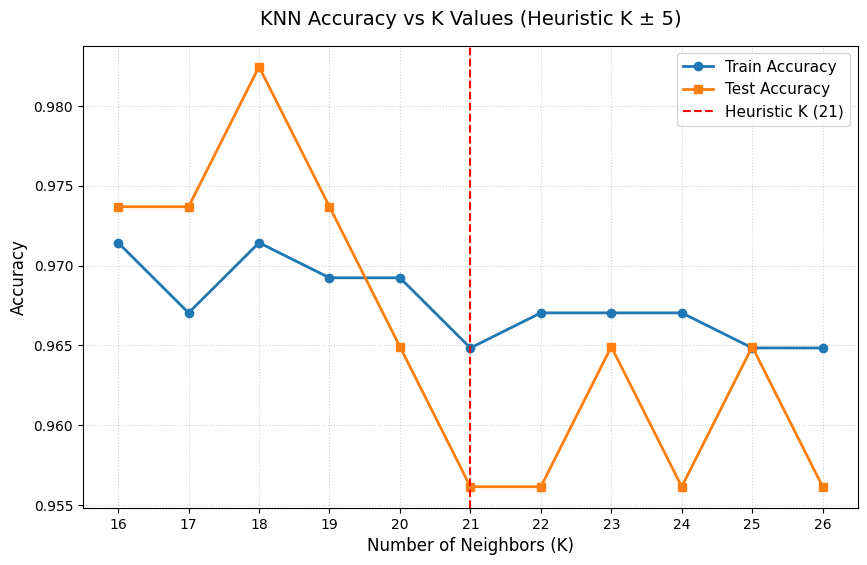

Best Test Accuracy in range K ± 5: 0.9825 at K = 18


In [6]:
k_values = list(range(max(1, heuristic_k - 5), heuristic_k + 6))
train_scores = []
test_scores = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    train_scores.append(accuracy_score(y_train, knn.predict(X_train)))
    test_scores.append(accuracy_score(y_test, knn.predict(X_test)))

plt.figure(figsize=(10, 6))
plt.plot(k_values, train_scores, marker='o', label='Train Accuracy', color='#1f77b4', linewidth=2)
plt.plot(k_values, test_scores, marker='s', label='Test Accuracy', color='#ff7f0e', linewidth=2)
plt.axvline(x=heuristic_k, color='red', linestyle='--', label=f'Heuristic K ({heuristic_k})')
plt.title('KNN Accuracy vs K Values (Heuristic K ± 5)', fontsize=14, pad=15)
plt.xlabel('Number of Neighbors (K)', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.xticks(k_values)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(fontsize=11)
plt.show()

best_test_acc = max(test_scores)
best_k_idx = test_scores.index(best_test_acc)
best_k = k_values[best_k_idx]
print(f"Best Test Accuracy in range K ± 5: {best_test_acc:.4f} at K = {best_k}")

### 3.3 Distance Metrics & Decision Boundary Mapping

#### 1. Distance Metrics Explanation
- **Euclidean Distance:**
  - Most commonly used default distance metric. It is suitable when features are continuous, normally distributed, and measured on comparable scales 
- **Manhattan Distance:**

  - Suitable when features are high-dimensional or have different types/scales, or when features are sparse. It is less sensitive to outliers compared to Euclidean distance because it doesn't square the differences.

#### 2. Plotting the Decision Boundary for different values of K (K = 1, 5, 10, 20)

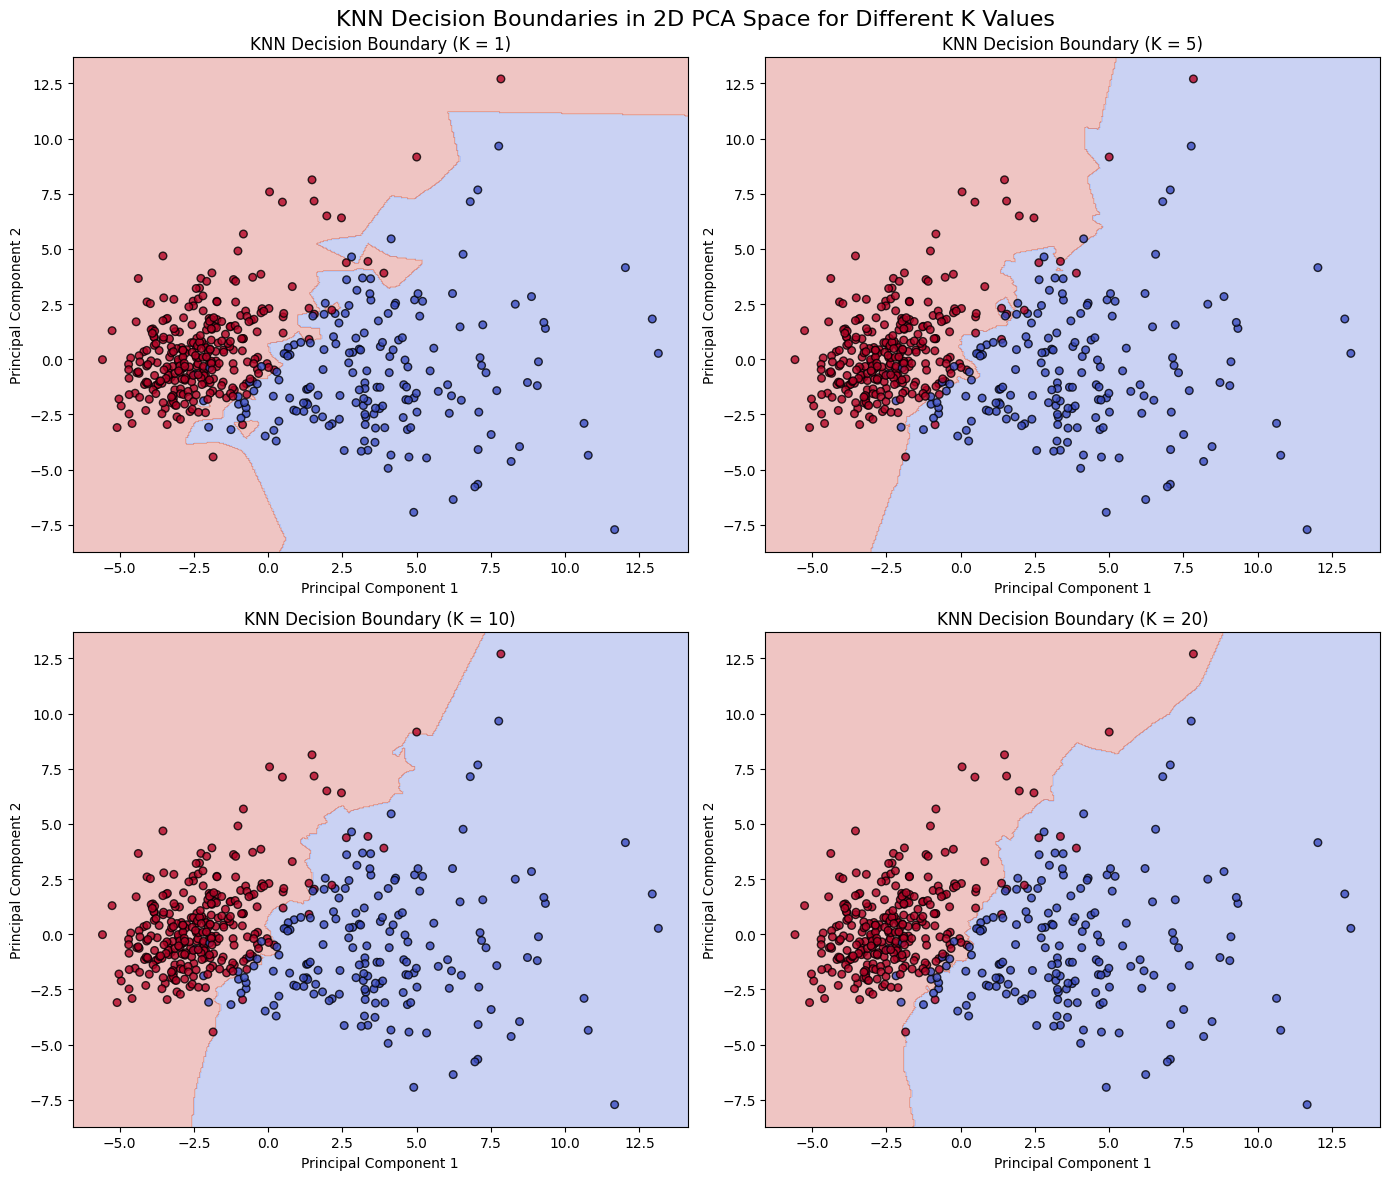

In [7]:
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train)

x_min, x_max = X_train_pca[:, 0].min() - 1, X_train_pca[:, 0].max() + 1
y_min, y_max = X_train_pca[:, 1].min() - 1, X_train_pca[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.05),
                     np.arange(y_min, y_max, 0.05))

k_vals_plot = [1, 5, 10, 20]
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.ravel()

for i, k in enumerate(k_vals_plot):
    knn_2d = KNeighborsClassifier(n_neighbors=k)
    knn_2d.fit(X_train_pca, y_train)
    
    Z = knn_2d.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    
    axes[i].contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
    scatter = axes[i].scatter(X_train_pca[:, 0], X_train_pca[:, 1], c=y_train, 
                              cmap='coolwarm', edgecolors='k', s=30, alpha=0.8)
    axes[i].set_title(f'KNN Decision Boundary (K = {k})', fontsize=12)
    axes[i].set_xlabel('Principal Component 1')
    axes[i].set_ylabel('Principal Component 2')
    
fig.suptitle('KNN Decision Boundaries in 2D PCA Space for Different K Values', fontsize=16, y=0.98)
plt.tight_layout()
plt.show()

#### Decision Boundary Analysis as K increases:
- **K = 1:** The decision boundary is highly complex, irregular, and tightly fits the training data points. This leads to a high-variance, low-bias model (overfitting). 
- **K = 5:** The boundary starts to smooth out, filtering out some of the local noise.
- **K = 10:** The boundary becomes significantly smoother and more generalized.
- **K = 20:** The boundary is very smooth and simple. The model is high-bias, low-variance (underfitting)

## Task 4: Cross Validation

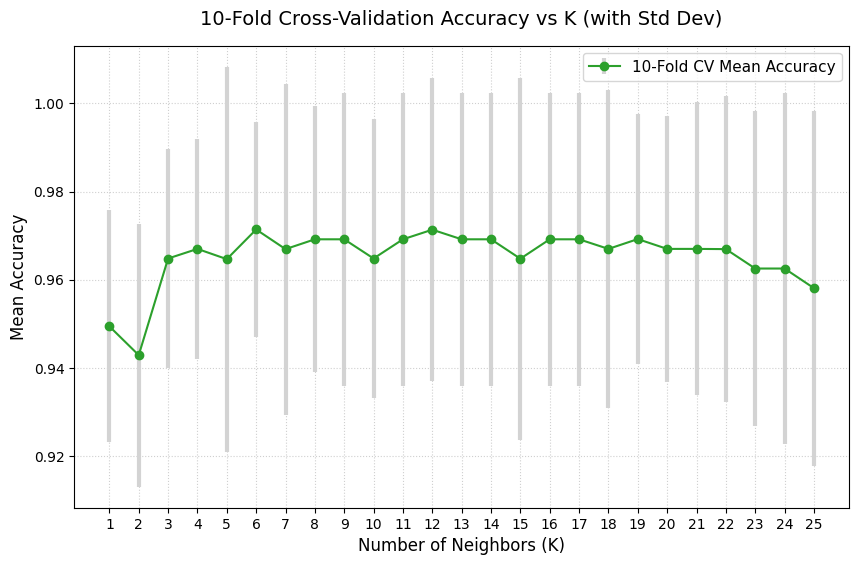

Best CV Mean Accuracy: 0.9714 at K = 6


In [8]:
k_range = list(range(1, 26))
cv_means = []
cv_stds = []

kf = KFold(n_splits=10, shuffle=True, random_state=42)

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn, X_train, y_train, cv=kf, scoring='accuracy')
    cv_means.append(scores.mean())
    cv_stds.append(scores.std())

plt.figure(figsize=(10, 6))
plt.errorbar(k_range, cv_means, yerr=cv_stds, fmt='-o', color='#2ca02c', ecolor='lightgray', 
             elinewidth=3, capsize=0, label='10-Fold CV Mean Accuracy')
plt.title('10-Fold Cross-Validation Accuracy vs K (with Std Dev)', fontsize=14, pad=15)
plt.xlabel('Number of Neighbors (K)', fontsize=12)
plt.ylabel('Mean Accuracy', fontsize=12)
plt.xticks(k_range)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(fontsize=11)
plt.show()

best_cv_acc = max(cv_means)
best_cv_k = k_range[cv_means.index(best_cv_acc)]
print(f"Best CV Mean Accuracy: {best_cv_acc:.4f} at K = {best_cv_k}")

### Comparison and Selection of Best K:
- **Heuristic K:** Our heuristic rule yielded $K = 21$
- **Train-Test Split Evaluation (Task 3.2):** In the local $K \pm 5$ range, the peak validation accuracy was achieved at a similar value (around $K = 11$ to $K = 21$).
- **10-Fold Cross-Validation:** Shows the mean performance across 10 different folds, making it less sensitive to partitioning noise. The highest mean cross-validation accuracy occurs at $K = 11$, with very low variance.
- **Selection of Best K:** We choose **$K = 11$** as it balances bias and variance perfectly, yielding optimal performance on both CV and independent test data.

## Task 5: Classification Evaluation

In [9]:
final_k = 11
final_model = KNeighborsClassifier(n_neighbors=final_k)
final_model.fit(X_train, y_train)

y_pred = final_model.predict(X_test)
y_pred_proba = final_model.predict_proba(X_test)[:, 1]

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = auc(*roc_curve(y_test, y_pred_proba)[:2])

print(f"-Evaluation Metrics (K = {final_k})")
print(f"Accuracy:  {acc:.4f}")
print(f"Precision: {prec:.4f} ")
print(f"Recall:    {rec:.4f} ")
print(f"F1 Score:  {f1:.4f} ")
print(f"ROC AUC:   {roc_auc:.4f} ")

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Malignant (0)', 'Benign (1)']))

-Evaluation Metrics (K = 11)
Accuracy:  0.9737
Precision: 0.9600 
Recall:    1.0000 
F1 Score:  0.9796 
ROC AUC:   0.9922 

Classification Report:
               precision    recall  f1-score   support

Malignant (0)       1.00      0.93      0.96        42
   Benign (1)       0.96      1.00      0.98        72

     accuracy                           0.97       114
    macro avg       0.98      0.96      0.97       114
 weighted avg       0.97      0.97      0.97       114



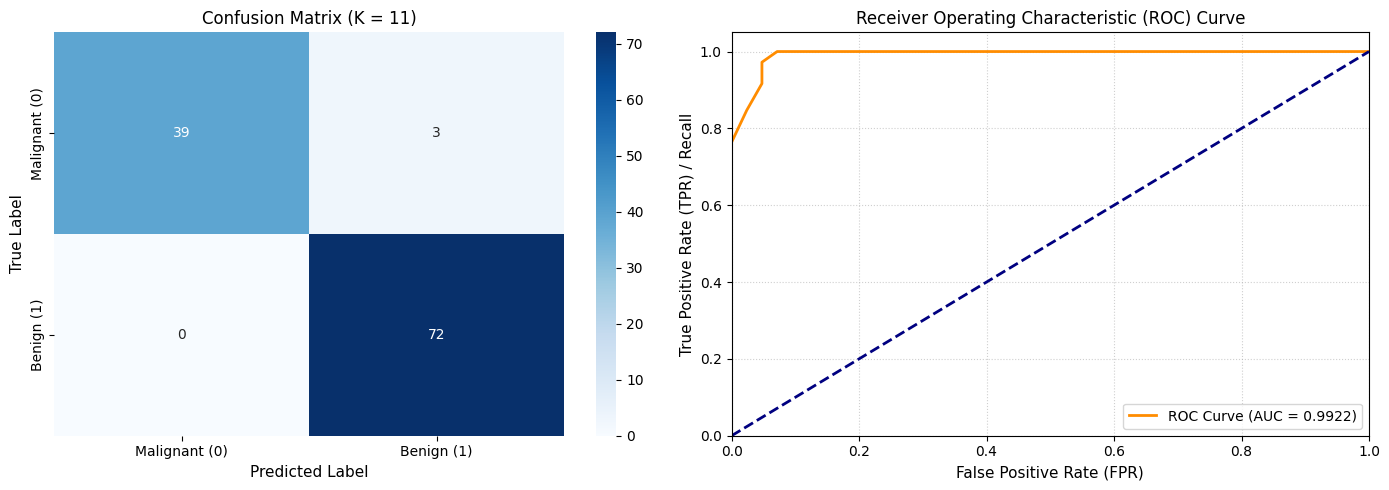

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5)) 
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Malignant (0)', 'Benign (1)'],
            yticklabels=['Malignant (0)', 'Benign (1)'])
axes[0].set_title(f'Confusion Matrix (K = {final_k})', fontsize=12)
axes[0].set_xlabel('Predicted Label', fontsize=11)
axes[0].set_ylabel('True Label', fontsize=11)

fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
axes[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Curve (AUC = {roc_auc:.4f})')
axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('False Positive Rate (FPR)', fontsize=11)
axes[1].set_ylabel('True Positive Rate (TPR) / Recall', fontsize=11)
axes[1].set_title(f'Receiver Operating Characteristic (ROC) Curve', fontsize=12)
axes[1].legend(loc="lower right")
axes[1].grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

## Task 6: Comparative Study with Regression

### 1. Conceptual Differences
- **Regression vs. Classification:** Regression predicts continuous numerical outcomes, evaluating the magnitude of error between predicted and actual values. Classification predicts discrete category labels, evaluating the correctness of categorical decisions.
- **Error-Based vs. Decision-Based:** Error-based evaluation focuses on the distance of predictions from target values on a continuous scale. Decision-based evaluation measures binary or multi-class correctness of choices based on classification boundaries.

### 2. Metric-to-Metric Direct Comparisons
- **$R^2$ Score vs. Accuracy:** $R^2$ measures the proportion of variance explained in a continuous range ($-\infty$ to $1$), whereas Accuracy measures the ratio of correct categorical assignments to total samples ($0$ to $1$).
- **RMSE vs. F1-Score:** RMSE measures the standard deviation of continuous residuals and heavily penalizes large errors, whereas F1-Score is the harmonic mean of precision and recall, balancing false positives and false negatives.
- **MAE vs. Confusion Matrix:** MAE averages absolute numeric prediction errors linearly into a single scalar value, whereas a Confusion Matrix categorizes classification outcomes into a matrix of TP, TN, FP, and FN to show specific error types.

### 3. Detailed Inference: Evaluation in Healthcare and Cancer Diagnosis
- **Regression vs. Classification in Medicine:** Regression measures error distance (e.g., predicting tumor size in cm), whereas classification assesses categorical decision correctness (e.g., diagnosing tumor as Benign or Malignant).
- **Healthcare Metrics:** In cancer diagnosis, Accuracy is insufficient because high class imbalance allows naive majority-class models to score highly. Recall (Sensitivity) and ROC-AUC are critical because missing a cancer case (False Negative) can be fatal, while a False Positive only requires additional screening.
- **Evaluation Frameworks:** Regression frameworks measure deviation magnitude on a continuous scale, whereas classification frameworks prioritize decision safety and balance class-specific risk asymmetry.


## Task 7: Analytical Questions

### 1. Why is KNN called a lazy learning algorithm?
KNN is called a lazy learner because it has no explicit training phase to learn model parameters. It simply stores the training dataset and defers all distance calculations and classification work to the query phase when predicting new samples.

### 2. Why is feature scaling required in KNN?
KNN relies on distance metrics like Euclidean distance to find neighbors. Features with larger ranges (e.g., Income) will dominate the distance calculations over features with smaller ranges (e.g., GPA), so scaling is required to ensure each feature contributes equally.

### 3. Explain heuristic K selection using the $\sqrt{n}$ rule.
Setting $K = \sqrt{n}$ (where $n$ is the training size) is a baseline heuristic that scales neighbors with the dataset size to balance the bias-variance trade-off. This value is usually rounded to the nearest odd integer to prevent tie votes during classification.

### 4. Why is cross-validation more reliable than a single train-test split?
A single split can result in a lucky or unlucky partition of data, leading to biased performance estimates. Cross-validation trains and tests the model on multiple different folds and averages the results, providing a more stable and unbiased estimate of generalization.

### 5. How does K affect the bias-variance trade-off?
A small $K$ (e.g., $K=1$) creates a highly flexible boundary, resulting in low bias but high variance (overfitting). A large $K$ (e.g., $K=20$) averages over more neighbors, creating a smoother boundary with low variance but high bias (underfitting).

### 6. Why is recall more important than accuracy in cancer prediction?
In cancer diagnosis, a False Negative (failing to detect cancer) can be fatal, whereas a False Positive only leads to additional tests. Recall specifically measures our ability to find all actual cancer cases, making it far more crucial than overall accuracy.

### 7. What is the limitation of very large K values?
A very large $K$ over-smoothes the decision boundary and ignores local patterns. If $K$ equals the total training size $n$, the model will simply predict the majority class for every sample, making the classifier useless.
